### **Helmet Violation Detection: Full Pipeline**

In this notebook, we will run the complete end-to-end helmet violation detection pipeline. The system takes a dashcam video as input, detects riders and motorcycles, tracks them across frames, and identifies riders who are not wearing a helmet The goal of this notebook is to see the entire system working together before diving into the individual stages. The following notebooks will break down each component of the pipeline in detail.



**Runtime:** Before running the notebook, make sure the runtime is set to a **GPU**:

*Runtime → Change runtime type → T4 GPU*

Running the detection pipeline on a CPU can be **roughly 10× slower** than using a GPU.

### **Setup**

`git clone` pulls the whole project from GitHub. `

`ultralytics` is the YOLO library that does the actual object detection.

`scipy` provides the Hungarian algorithm we use for matching riders to
motorcycles.

In [1]:
!git clone -q https://github.com/shreyamali17/helmet-violation-detection.git
%cd helmet-violation-detection/project

!pip install -q ultralytics scipy

!mkdir -p models sample_videos output

/content/helmet-violation-detection/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.2 MB/s eta 0:00:00


### **Imports**

Each import here is one stage of the pipeline. R

| Module | What it does |
|---|---|
| `detection` | Turns raw YOLO output into clean per-class dictionaries |
| `association` | Matches riders to motorcycles, helmets to riders, plates to motorcycles |
| `temporal` | Decides a violation using many frames, not one |
| `rm_instance` | Remembers each rider–motorcycle pair across the whole video |
| `visualization` | Draws the boxes and labels onto frames |

The pipeline logic lives in `.py` files rather than in notebook cells. That's
deliberate: it means any notebook can import the same code, and you can edit
one stage without touching the others.

In [4]:
%cd /content/helmet-violation-detection/project/pipeline

import os
from ultralytics import YOLO

import config
from detection import get_frame_detections
from association import (associate_riders_to_motorcycles,
                         associate_heads_to_riders,
                         associate_plates_to_motorcycles)
from temporal import smooth_helmet_status, decide_violation
from rm_instance import RMInstanceManager
from visualization import draw_rm_instances

/content/helmet-violation-detection/project/pipeline
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [5]:
import config
config.MODEL_PATH = "/content/helmet-violation-detection/project/models/best.pt"
config.OUTPUT_DIR = "/content/output"

### **Pipeline**

The pipeline processes the video **one frame at a time**. For each frame, five main steps take place:

1. **Detect** : YOLO detects motorcycles, riders, helmets, no-helmets, and number plates.  
   `model.track()` also assigns a **unique tracking ID** to each detected object, allowing us to follow it across frames.

2. **Associate riders with motorcycles** : determine which rider belongs to which motorcycle.  

3. **Associate heads with riders** : determine whether each rider's head is associated with a **helmet** or a **no-helmet** detection.

4. **Update the running decision** : for every tracked rider, combine the observations collected so far and determine whether there is enough evidence to classify them as a violation.

5. **Capture evidence** : when a rider is confirmed as a violation for the first time, save an **annotated frame** as evidence.


In [6]:
def run_pipeline(model_path=None, video_path=None, frame_limit=None, save_sample_frames=True):
    model_path = model_path or config.MODEL_PATH
    video_path = video_path or config.VIDEO_PATH
    frame_limit = frame_limit if frame_limit is not None else config.FRAME_LIMIT

    model = YOLO(model_path)

    results = model.track(
        source=video_path, classes=list(config.CLASS_NAMES.keys()),
        tracker=config.TRACKER, persist=True, stream=True, verbose=False,
    )

    manager = RMInstanceManager()
    observations = {}
    plate_matches = {}
    sample_frames = []

    frame_count = 0
    for i, r in enumerate(results):
        if frame_limit is not None and i >= frame_limit:
            break
        frame_count = i + 1

        det, confs = get_frame_detections(r)

        for rider_id, moto_id in associate_riders_to_motorcycles(det["rider"], det["motorcycle"]):
            manager.get_or_create(rider_id, moto_id)

        head_matches = associate_heads_to_riders(
            det["rider"], det["helmet"], det["no_helmet"],
            helmet_confs=confs["helmet"], no_helmet_confs=confs["no_helmet"],
        )
        for rider_id, (status, model_conf) in head_matches.items():
            observations.setdefault(rider_id, []).append((status, model_conf))

        for moto_id, plate_id in associate_plates_to_motorcycles(det["motorcycle"], det["license_plate"]).items():
            plate_matches[moto_id] = det["license_plate"][plate_id]

        for rider_id, inst in manager.instances_by_rider.items():
            smoothed = smooth_helmet_status(observations, rider_id)
            inst.helmet_status = smoothed[0] if smoothed else None
            inst.confidence = smoothed[1] if smoothed else None
            inst.is_violation = decide_violation(smoothed)
            if inst.motorcycle_id in plate_matches:
                inst.plate_box = plate_matches[inst.motorcycle_id]

        if save_sample_frames:
            for rider_id in det["rider"]:
                inst = manager.instances_by_rider.get(rider_id)
                already_captured = any(rid == rider_id for rid, _, _ in sample_frames)
                if inst and inst.is_violation is True and not already_captured:
                    annotated = draw_rm_instances(r.orig_img, det, manager.instances_by_rider, highlight_rider_id=rider_id)
                    sample_frames.append((rider_id, i, annotated))

    print(f"Processed {frame_count} frames from: {video_path}")
    print(f"Model: {model_path}")
    for k, v in manager.summary().items():
        print(f"  {k}: {v}")

    return manager, observations, plate_matches, sample_frames

In [7]:
def save_outputs(manager, sample_frames, output_dir=None):
    output_dir = output_dir or config.OUTPUT_DIR
    os.makedirs(output_dir, exist_ok=True)

    report_path = os.path.join(output_dir, "rm_instances_report.txt")
    with open(report_path, "w") as f:
        for inst in manager.all_instances():
            f.write(repr(inst) + "\n")
    print(f"\nSaved report: {report_path}")

    import cv2
    for rider_id, frame_num, img in sample_frames:
        img_path = os.path.join(output_dir, f"violation_rider{rider_id}_frame{frame_num}.png")
        cv2.imwrite(img_path, img)
    if sample_frames:
        print(f"Saved {len(sample_frames)} violation snapshot(s) to: {output_dir}")


In [10]:
manager, observations, plate_matches, sample_frames = run_pipeline(
    video_path="/content/20211125082353_0060.mp4",
    frame_limit=300,
)

Processed 300 frames from: /content/20211125082353_0060.mp4
Model: /content/helmet-violation-detection/project/models/best.pt
  total_instances: 39
  confident_helmet_status: 18
  confirmed_violations: 3


### **Evidence**

Each image below is a frame where a violation was confirmed, with the boxes
drawn on. Colours come from `visualization.py`:

- **red** : confirmed violation
- **green** : confirmed wearing a helmet
- **orange** : tracked, but not enough evidence yet




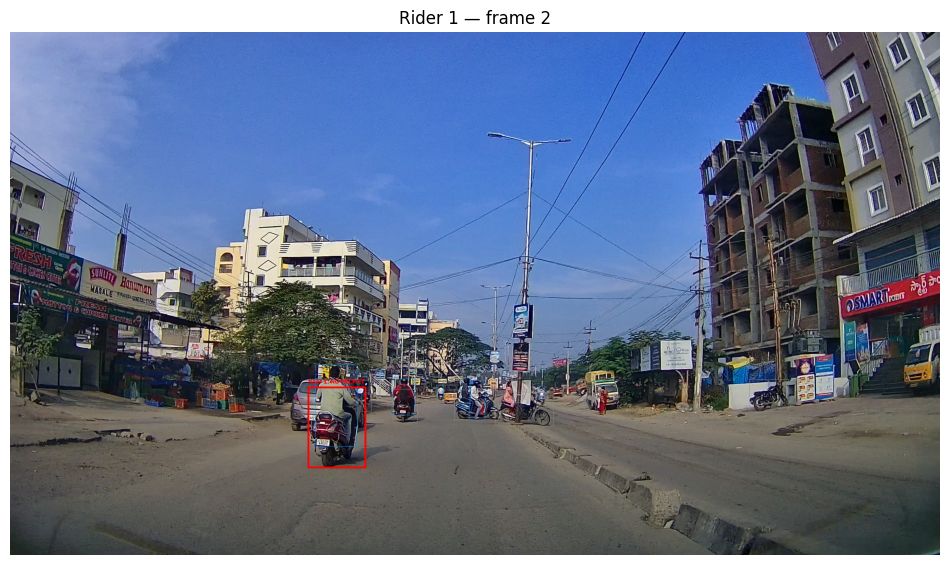

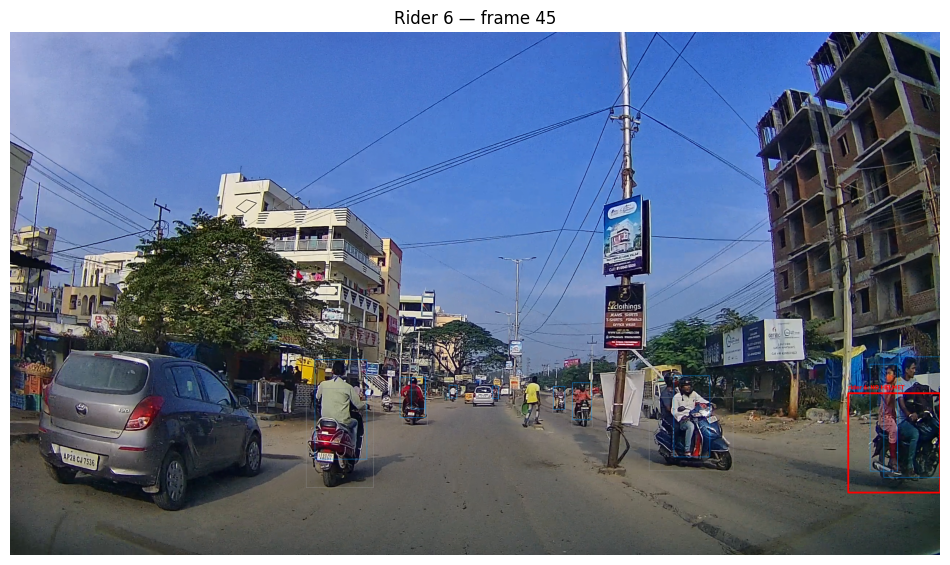

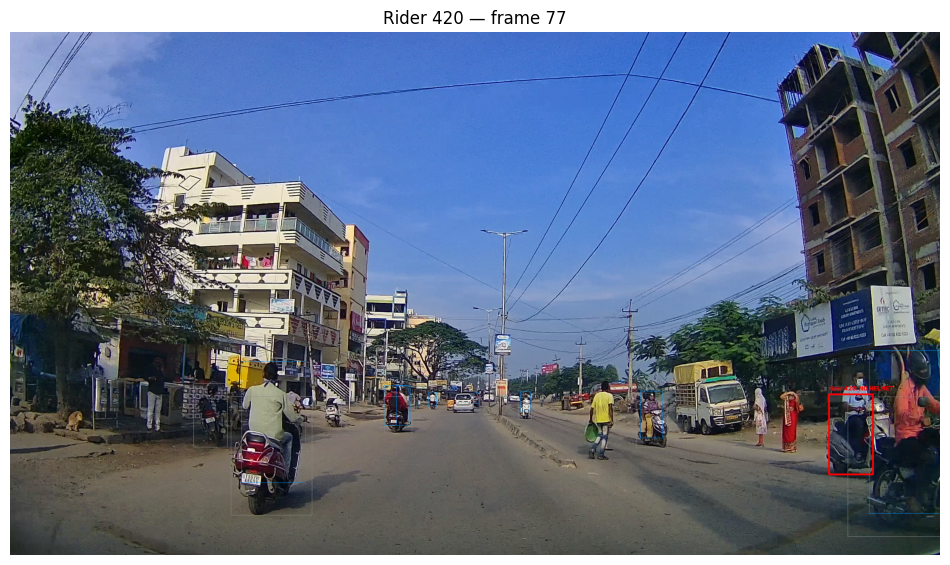

In [11]:
import matplotlib.pyplot as plt
import cv2

for rider_id, frame_num, img in sample_frames:
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Rider {rider_id} — frame {frame_num}")
    plt.axis("off")
    plt.show()